# Phishing con Granite + Features Estructuradas + MLP

Este notebook es una version del flujo base, pero ahora usa columnas separadas del dataset fuente para aprovechar mejor la informacion del correo.

La idea es combinar dos tipos de señal:

1. **Texto libre**: `subject` y `body` se convierten en embeddings con Granite.
2. **Variables estructuradas**: `sender`, `urls` y estadisticas del texto se convierten en features numericas.

Al final, ambos bloques se concatenan y se entrenan con un `MLP`.

## 1. Configuracion

Este notebook guarda sus artefactos en `artifacts_structured/` para no mezclar resultados con el notebook original.

In [1]:
from __future__ import annotations

import hashlib
import math
import random
import re
from email.utils import parseaddr
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

sns.set_theme(style='whitegrid')

SEED = 42
DATA_DIR = Path('dataset')
ARTIFACT_DIR = Path('artifacts_structured')
MODEL_NAME = 'ibm-granite/granite-embedding-97m-multilingual-r2'

SOURCE_FILES = [
    'CEAS_08.csv',
    'Enron.csv',
    'Ling.csv',
    'Nazario.csv',
    'Nigerian_Fraud.csv',
    'SpamAssasin.csv',
]

FULL_CACHE = ARTIFACT_DIR / 'granite_text_embeddings_full.pt'
PARTIAL_CACHE = ARTIFACT_DIR / 'granite_text_embeddings_partial.pt'
METADATA_PATH = ARTIFACT_DIR / 'phishing_structured_metadata.parquet'
NUMERIC_FEATURES_PATH = ARTIFACT_DIR / 'numeric_features.parquet'
MLP_PATH = ARTIFACT_DIR / 'mlp_structured_model.pt'
TEST_METRICS_PATH = ARTIFACT_DIR / 'test_metrics.json'

BATCH_SIZE_EMBED = 64  # Adjust based on GPU memory
BATCH_SIZE_MLP = 256
MAX_LENGTH = 2048
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MAX_EPOCHS = 50
PATIENCE = 6
LR = 1e-3
WEIGHT_DECAY = 1e-4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True

FREE_EMAIL_DOMAINS = {
    'gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'live.com',
    'aol.com', 'proton.me', 'protonmail.com', 'icloud.com', 'gmx.com',
    'mail.com', 'yandex.com', 'zoho.com'
}
URGENT_KEYWORDS = ['urgent', 'verify', 'account', 'password', 'limited', 'suspend', 'winner', 'free', 'security']
URL_RE = re.compile(r'(https?://\S+|www\.\S+)', re.IGNORECASE)
IP_URL_RE = re.compile(r'https?://(?:\d{1,3}\.){3}\d{1,3}(?::\d+)?(?:/\S*)?', re.IGNORECASE)


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()
ARTIFACT_DIR.mkdir(exist_ok=True)
print('device:', DEVICE)
print('model:', MODEL_NAME)
print('artifacts:', ARTIFACT_DIR.resolve())

device: cuda
model: ibm-granite/granite-embedding-97m-multilingual-r2
artifacts: /home/randy/Python/Phishing/artifacts_structured


## 2. Carga del dataset

Aqui no se usa `phishing_email.csv`, porque ese archivo ya viene fusionado y solo conserva `text_combined`. Para aprovechar `sender`, `subject`, `body` y `urls`, se cargan los CSV fuente originales y se normalizan a un esquema comun.

In [2]:
def clean_text(value: object) -> str:
    if pd.isna(value):
        return ''
    text = str(value)
    text = ' '.join(text.split())
    return text.strip()


def safe_int(value, default: int = 0) -> int:
    try:
        if pd.isna(value):
            return default
        return int(float(value))
    except Exception:
        return default


def normalize_source_frame(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    result = pd.DataFrame(index=df.index)

    for col in ['sender', 'receiver', 'date', 'subject', 'body']:
        if col in df.columns:
            result[col] = df[col]
        else:
            result[col] = ''

    if 'urls' in df.columns:
        result['urls'] = df['urls']
    else:
        result['urls'] = 0

    result['label'] = df['label']
    result['source_file'] = path.name
    result['source_row_id'] = np.arange(len(result), dtype=np.int64)
    return result


frames = []
for name in SOURCE_FILES:
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'No se encontro {path}')
    frames.append(normalize_source_frame(path))

raw_df = pd.concat(frames, ignore_index=True)
print('raw shape:', raw_df.shape)
print('columns:', raw_df.columns.tolist())
display(raw_df.head())
print('label counts:')
display(raw_df['label'].value_counts(dropna=False).sort_index())

raw shape: (82486, 9)
columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label', 'source_file', 'source_row_id']


,sender,receiver,date,subject,body,urls,label,source_file,source_row_id
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,CEAS_08.csv,0
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,CEAS_08.csv,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,CEAS_08.csv,2
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,1,0,CEAS_08.csv,3
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,CEAS_08.csv,4


label counts:


label
0    39595
1    42891
Name: count, dtype: int64

## 3. Limpieza y features

La preparacion crea tres cosas a la vez:

1. un texto principal para el embedding,
2. un conjunto de features numericas,
3. un `text_hash` para evitar que el mismo correo se mezcle entre particiones.

In [3]:

def parse_sender(sender: object) -> dict:
    sender_clean = clean_text(sender)
    display_name, email_addr = parseaddr(sender_clean)
    email_addr = email_addr.strip().lower()
    display_name = display_name.strip()

    local = ''
    domain = ''
    if '@' in email_addr:
        local, domain = email_addr.split('@', 1)
        local = local.strip().lower()
        domain = domain.strip().lower()

    return {
        'sender_missing': int(sender_clean == ''),
        'sender_length': len(sender_clean),
        'sender_has_email': int('@' in email_addr),
        'sender_display_name_length': len(display_name),
        'sender_email_local_length': len(local),
        'sender_domain_length': len(domain),
        'sender_domain_dot_count': domain.count('.'),
        'sender_domain_hyphen_count': domain.count('-'),
        'sender_domain_digit_count': sum(ch.isdigit() for ch in domain),
        'sender_is_free_provider': int(domain in FREE_EMAIL_DOMAINS),
        'sender_is_mailer_daemon': int('mailer-daemon' in sender_clean.lower() or 'mail system internal data' in sender_clean.lower()),
    }


def text_stats(text: object, prefix: str, raw_text: object | None = None) -> dict:
    text_clean = clean_text(text)
    text_lower = text_clean.lower()
    raw_value = '' if raw_text is None or pd.isna(raw_text) else str(raw_text)
    letters = [ch for ch in text_clean if ch.isalpha()]
    alpha_count = len(letters)
    upper_count = sum(ch.isupper() for ch in letters)
    digit_count = sum(ch.isdigit() for ch in text_clean)

    return {
        f'{prefix}_missing': int(text_clean == ''),
        f'{prefix}_length': len(text_clean),
        f'{prefix}_word_count': len(text_clean.split()),
        f'{prefix}_line_count': raw_value.count('\n') + (1 if raw_value else 0),
        f'{prefix}_exclamation_count': text_clean.count('!'),
        f'{prefix}_question_count': text_clean.count('?'),
        f'{prefix}_uppercase_ratio': (upper_count / alpha_count) if alpha_count else 0.0,
        f'{prefix}_digit_count': digit_count,
        f'{prefix}_has_urgent_keyword': int(any(keyword in text_lower for keyword in URGENT_KEYWORDS)),
    }


def body_url_stats(body: object) -> dict:
    raw_body = '' if pd.isna(body) else str(body)
    lowered = raw_body.lower()
    url_matches = URL_RE.findall(raw_body)
    return {
        'body_url_count_regex': len(url_matches),
        'body_has_http': int('http://' in lowered),
        'body_has_https': int('https://' in lowered),
        'body_has_www': int('www.' in lowered),
        'body_has_ip_url': int(bool(IP_URL_RE.search(raw_body))),
        'body_url_like_token_count': len(url_matches),
    }


def build_record(row: pd.Series) -> dict:
    sender_clean = clean_text(row.get('sender', ''))
    receiver_clean = clean_text(row.get('receiver', ''))
    date_clean = clean_text(row.get('date', ''))
    subject_clean = clean_text(row.get('subject', ''))
    body_clean = clean_text(row.get('body', ''))
    urls_value = safe_int(row.get('urls', 0), default=0)

    embedding_text = f'Subject: {subject_clean}\nBody: {body_clean}'.strip()
    hash_basis = '\n'.join([sender_clean, subject_clean, body_clean])

    record = {
        'sender_clean': sender_clean,
        'receiver_clean': receiver_clean,
        'date_clean': date_clean,
        'subject_clean': subject_clean,
        'body_clean': body_clean,
        'embedding_text': embedding_text,
        'has_url_flag': int(urls_value > 0),
        'text_hash': hashlib.sha256(hash_basis.encode('utf-8')).hexdigest(),
    }

    record.update(parse_sender(sender_clean))
    record.update(text_stats(subject_clean, 'subject'))
    record.update(text_stats(body_clean, 'body', raw_text=row.get('body', '')))
    record.update(body_url_stats(row.get('body', '')))
    record.update({
        'receiver_missing': int(receiver_clean == ''),
        'date_missing': int(date_clean == ''),
    })
    return record


records = [build_record(row) for _, row in raw_df.iterrows()]
feature_df = pd.DataFrame(records)
full_df = pd.concat([raw_df.reset_index(drop=True), feature_df], axis=1)
full_df['row_id'] = np.arange(len(full_df), dtype=np.int64)
full_df['label'] = full_df['label'].astype(int)
full_df = full_df[full_df['embedding_text'].str.strip() != ''].copy()
full_df['text_hash'] = full_df['text_hash'].astype(str)

print('clean shape:', full_df.shape)
print('unique hashes:', full_df['text_hash'].nunique())
print('duplicate extra rows:', int(full_df['text_hash'].duplicated().sum()))
display(full_df[['sender_clean', 'subject_clean', 'has_url_flag', 'label']].head())

feature_cols = [
    col for col in feature_df.columns
    if col not in {'sender_clean', 'receiver_clean', 'date_clean', 'subject_clean', 'body_clean', 'embedding_text', 'text_hash'}
]

numeric_only_df = full_df[['row_id', 'label', 'source_file', 'text_hash'] + feature_cols].copy()
numeric_only_df.to_parquet(NUMERIC_FEATURES_PATH, index=False)
print('saved numeric features ->', NUMERIC_FEATURES_PATH)


clean shape: (82486, 55)
unique hashes: 82095
duplicate extra rows: 391


,sender_clean,subject_clean,has_url_flag,label
0,Young Esposito <Young@iworld.de>,Never agree to be a loser,1,1
1,Mok <ipline's1983@icable.ph>,Befriend Jenna Jameson,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,CNN.com Daily Top 10,1,1
3,Michael Parker <ivqrnai@pobox.com>,Re: svn commit: r619753 - in /spamassassin/tru...,1,0
4,Gretchen Suggs <externalsep1@loanofficertool.com>,SpecialPricesPharmMoreinfo,1,1


saved numeric features -> artifacts_structured/numeric_features.parquet


In [4]:
def choose_best_fold(splitter, X, y, groups, target_fraction: float):
    y = np.asarray(y)
    total_pos_rate = float(y.mean())
    best = None
    for fold_id, (_, fold_idx) in enumerate(splitter.split(X, y, groups)):
        fold_idx = np.asarray(fold_idx)
        fold_fraction = len(fold_idx) / len(y)
        fold_pos_rate = float(y[fold_idx].mean()) if len(fold_idx) else 0.0
        score = abs(fold_fraction - target_fraction) + 0.35 * abs(fold_pos_rate - total_pos_rate)
        candidate = {
            'score': score,
            'fold_id': fold_id,
            'fold_idx': fold_idx,
            'fold_fraction': fold_fraction,
            'fold_pos_rate': fold_pos_rate,
        }
        if best is None or candidate['score'] < best['score']:
            best = candidate
    if best is None:
        raise RuntimeError('No se pudo elegir un fold valido')
    return best


X_dummy = np.zeros(len(full_df), dtype=np.int8)
y = full_df['label'].to_numpy()
groups = full_df['text_hash'].to_numpy()

outer = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
best_test = choose_best_fold(outer, X_dummy, y, groups, target_fraction=TEST_SIZE)
test_idx = np.sort(best_test['fold_idx'])
remaining_mask = np.ones(len(full_df), dtype=bool)
remaining_mask[test_idx] = False
remaining_df = full_df.loc[remaining_mask].reset_index(drop=True)

inner_X = np.zeros(len(remaining_df), dtype=np.int8)
inner_y = remaining_df['label'].to_numpy()
inner_groups = remaining_df['text_hash'].to_numpy()
inner_target = VAL_SIZE / (1.0 - TEST_SIZE)
inner = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED + 1)
best_val = choose_best_fold(inner, inner_X, inner_y, inner_groups, target_fraction=inner_target)
val_idx_local = np.sort(best_val['fold_idx'])

remaining_df['split'] = 'train'
remaining_df.loc[val_idx_local, 'split'] = 'val'
test_df = full_df.loc[test_idx].copy()
test_df['split'] = 'test'

split_df = pd.concat([remaining_df, test_df], ignore_index=True).sort_values('row_id').reset_index(drop=True)
if not (split_df.groupby('text_hash')['split'].nunique() == 1).all():
    raise AssertionError('Hay fuga de hashes entre splits')

print('split counts:')
display(split_df['split'].value_counts())
print('split label table:')
display(pd.crosstab(split_df['split'], split_df['label']))

metadata_cols = ['row_id', 'source_file', 'source_row_id', 'label', 'split', 'text_hash', 'sender_clean', 'receiver_clean', 'date_clean', 'subject_clean', 'body_clean', 'embedding_text', 'has_url_flag']
structured_metadata = split_df[metadata_cols].copy()
structured_metadata.to_parquet(METADATA_PATH, index=False)
print('saved metadata ->', METADATA_PATH)

split counts:


split
train    58913
test     11790
val      11783
Name: count, dtype: int64

split label table:


label,0,1
split,,
test,5647,6143
train,28263,30650
val,5685,6098


saved metadata -> artifacts_structured/phishing_structured_metadata.parquet


## 4. Embeddings Granite

Aqui se usa solo el texto combinado `Subject: ... / Body: ...` para aprovechar la parte linguistica del correo. Las features numericas se guardan por separado y se concatenan mas tarde.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
encoder.eval()


def encode_batch(texts: list[str]) -> torch.Tensor:
    batch = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt',
    )
    batch = {key: value.to(DEVICE) for key, value in batch.items()}
    with torch.inference_mode():
        if DEVICE.type == 'cuda':
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = encoder(**batch)
        else:
            outputs = encoder(**batch)
        embeddings = outputs.last_hidden_state[:, 0]
        embeddings = F.normalize(embeddings, p=2, dim=1)
    return embeddings.float().cpu()


def build_embedding_cache(frame: pd.DataFrame, batch_size: int = BATCH_SIZE_EMBED, checkpoint_every: int = 200) -> dict:
    if FULL_CACHE.exists():
        print('cargando cache completo:', FULL_CACHE)
        return torch.load(FULL_CACHE, map_location='cpu', weights_only=False)

    start_index = 0
    chunks = []
    row_ids = []
    labels = []
    hashes = []

    if PARTIAL_CACHE.exists():
        partial = torch.load(PARTIAL_CACHE, map_location='cpu', weights_only=False)
        start_index = int(partial['next_index'])
        chunks.append(partial['embeddings'])
        row_ids.extend(partial['row_ids'])
        labels.extend(partial['labels'])
        hashes.extend(partial['text_hashes'])
        print('reanudando desde', start_index)

    texts = frame['embedding_text'].tolist()
    all_row_ids = frame['row_id'].tolist()
    all_labels = frame['label'].tolist()
    all_hashes = frame['text_hash'].tolist()

    total_batches = math.ceil((len(texts) - start_index) / batch_size)
    for batch_number, batch_start in enumerate(tqdm(range(start_index, len(texts), batch_size), desc='embedding', total=total_batches)):
        batch_end = min(batch_start + batch_size, len(texts))
        batch_embeddings = encode_batch(texts[batch_start:batch_end])
        chunks.append(batch_embeddings)
        row_ids.extend(all_row_ids[batch_start:batch_end])
        labels.extend(all_labels[batch_start:batch_end])
        hashes.extend(all_hashes[batch_start:batch_end])

        if (batch_number + 1) % checkpoint_every == 0 or batch_end == len(texts):
            partial_state = {
                'embeddings': torch.cat(chunks, dim=0),
                'row_ids': row_ids,
                'labels': labels,
                'text_hashes': hashes,
                'next_index': batch_end,
                'model_name': MODEL_NAME,
            }
            torch.save(partial_state, PARTIAL_CACHE)
            print('checkpoint guardado en', PARTIAL_CACHE)

    embeddings = torch.cat(chunks, dim=0)
    payload = {
        'embeddings': embeddings,
        'row_ids': row_ids,
        'labels': labels,
        'text_hashes': hashes,
        'model_name': MODEL_NAME,
        'max_length': MAX_LENGTH,
        'created_at': pd.Timestamp.now(tz='UTC').isoformat(),
    }
    torch.save(payload, FULL_CACHE)
    if PARTIAL_CACHE.exists():
        PARTIAL_CACHE.unlink()
    return payload


embedding_cache = build_embedding_cache(split_df)
print('embeddings shape:', tuple(embedding_cache['embeddings'].shape))
print('embedding dtype:', embedding_cache['embeddings'].dtype)
if embedding_cache['embeddings'].shape[1] != 384:
    raise AssertionError('Se esperaba una dimension de embedding de 384')
if torch.isnan(embedding_cache['embeddings']).any() or torch.isinf(embedding_cache['embeddings']).any():
    raise AssertionError('Los embeddings contienen NaN o inf')

Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

embedding:   0%|          | 0/1289 [00:00<?, ?it/s]

checkpoint guardado en artifacts_structured/granite_text_embeddings_partial.pt
checkpoint guardado en artifacts_structured/granite_text_embeddings_partial.pt
checkpoint guardado en artifacts_structured/granite_text_embeddings_partial.pt
checkpoint guardado en artifacts_structured/granite_text_embeddings_partial.pt
checkpoint guardado en artifacts_structured/granite_text_embeddings_partial.pt
checkpoint guardado en artifacts_structured/granite_text_embeddings_partial.pt
checkpoint guardado en artifacts_structured/granite_text_embeddings_partial.pt
embeddings shape: (82486, 384)
embedding dtype: torch.float32


## 5. Entrenamiento del MLP

A partir de aqui se usa el embedding cacheado y las features numericas escaladas. El modelo final no vuelve a pasar por Granite durante el entrenamiento del clasificador.

In [7]:
cache = torch.load(FULL_CACHE, map_location='cpu', weights_only=False)
metadata = pd.read_parquet(METADATA_PATH).sort_values('row_id').reset_index(drop=True)
numeric_df = pd.read_parquet(NUMERIC_FEATURES_PATH).sort_values('row_id').reset_index(drop=True)

embedding_index = pd.Index(cache['row_ids'])
metadata = metadata.set_index('row_id').loc[embedding_index].reset_index()
numeric_df = numeric_df.set_index('row_id').loc[embedding_index].reset_index()

embeddings = cache['embeddings'].float()
labels = torch.tensor(cache['labels'], dtype=torch.long)
feature_cols = [col for col in numeric_df.columns if col not in {'row_id', 'label', 'source_file', 'split', 'text_hash'}]

split_masks = {name: metadata['split'].eq(name).to_numpy() for name in ['train', 'val', 'test']}

X_num = numeric_df[feature_cols].astype(np.float32)
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num.loc[split_masks['train']])
X_num_val = scaler.transform(X_num.loc[split_masks['val']])
X_num_test = scaler.transform(X_num.loc[split_masks['test']])

X_emb_train = embeddings[split_masks['train']]
y_train = labels[split_masks['train']]
X_emb_val = embeddings[split_masks['val']]
y_val = labels[split_masks['val']]
X_emb_test = embeddings[split_masks['test']]
y_test = labels[split_masks['test']]

X_train = torch.cat([X_emb_train, torch.tensor(X_num_train, dtype=torch.float32)], dim=1)
X_val = torch.cat([X_emb_val, torch.tensor(X_num_val, dtype=torch.float32)], dim=1)
X_test = torch.cat([X_emb_test, torch.tensor(X_num_test, dtype=torch.float32)], dim=1)

print('feature count:', len(feature_cols))
print('final input dim:', X_train.shape[1])
print('train/val/test sizes:', len(X_train), len(X_val), len(X_test))

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE_MLP, shuffle=True, pin_memory=DEVICE.type == 'cuda')
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE_MLP, shuffle=False, pin_memory=DEVICE.type == 'cuda')
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE_MLP, shuffle=False, pin_memory=DEVICE.type == 'cuda')


class StructuredPhishingMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def evaluate_model(model: nn.Module, loader: DataLoader):
    model.eval()
    all_logits = []
    all_targets = []
    with torch.inference_mode():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            all_logits.append(logits.detach().cpu())
            all_targets.append(yb.detach().cpu())
    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_targets, dim=0).numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(axis=1)

    precision, recall, f1, support = precision_recall_fscore_support(targets, preds, labels=[0, 1], zero_division=0)
    metrics = {
        'accuracy': accuracy_score(targets, preds),
        'precision_0': float(precision[0]),
        'recall_0': float(recall[0]),
        'f1_0': float(f1[0]),
        'precision_1': float(precision[1]),
        'recall_1': float(recall[1]),
        'f1_1': float(f1[1]),
        'macro_f1': float(f1.mean()),
        'support_0': int(support[0]),
        'support_1': int(support[1]),
    }
    try:
        metrics['roc_auc'] = float(roc_auc_score(targets, probs[:, 1]))
    except ValueError:
        metrics['roc_auc'] = float('nan')
    return metrics, targets, preds, probs


mlp = StructuredPhishingMLP(input_dim=X_train.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = []
best_val_score = -1.0
best_state = None
best_epoch = 0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    mlp.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = mlp(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.item()))

    val_metrics, _, _, _ = evaluate_model(mlp, val_loader)
    train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
    history.append({'epoch': epoch, 'train_loss': train_loss, **val_metrics})
    print(f"epoch {epoch:02d} | train_loss={train_loss:.4f} | val_macro_f1={val_metrics['macro_f1']:.4f} | val_acc={val_metrics['accuracy']:.4f}")

    if val_metrics['macro_f1'] > best_val_score + 1e-5:
        best_val_score = val_metrics['macro_f1']
        best_state = {
            'model_state_dict': mlp.state_dict(),
            'model_config': {
                'input_dim': X_train.shape[1],
                'feature_cols': feature_cols,
            },
            'epoch': epoch,
            'val_metrics': val_metrics,
            'scaler': scaler,
        }
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print('early stopping')
        break

if best_state is None:
    raise RuntimeError('No se obtuvo un modelo valido')

mlp.load_state_dict(best_state['model_state_dict'])
torch.save(
    {
        **best_state,
        'history': history,
        'best_epoch': best_epoch,
        'model_name': MODEL_NAME,
    },
    MLP_PATH,
)
print('saved model ->', MLP_PATH)

display(pd.DataFrame(history).tail())

feature count: 39
final input dim: 423
train/val/test sizes: 58913 11783 11790
epoch 01 | train_loss=0.1435 | val_macro_f1=0.9772 | val_acc=0.9773
epoch 02 | train_loss=0.0680 | val_macro_f1=0.9803 | val_acc=0.9803
epoch 03 | train_loss=0.0571 | val_macro_f1=0.9820 | val_acc=0.9820
epoch 04 | train_loss=0.0494 | val_macro_f1=0.9792 | val_acc=0.9792
epoch 05 | train_loss=0.0454 | val_macro_f1=0.9846 | val_acc=0.9846
epoch 06 | train_loss=0.0405 | val_macro_f1=0.9845 | val_acc=0.9845
epoch 07 | train_loss=0.0382 | val_macro_f1=0.9827 | val_acc=0.9827
epoch 08 | train_loss=0.0350 | val_macro_f1=0.9836 | val_acc=0.9836
epoch 09 | train_loss=0.0329 | val_macro_f1=0.9858 | val_acc=0.9858
epoch 10 | train_loss=0.0321 | val_macro_f1=0.9859 | val_acc=0.9859
epoch 11 | train_loss=0.0294 | val_macro_f1=0.9852 | val_acc=0.9852
epoch 12 | train_loss=0.0278 | val_macro_f1=0.9868 | val_acc=0.9868
epoch 13 | train_loss=0.0268 | val_macro_f1=0.9865 | val_acc=0.9865
epoch 14 | train_loss=0.0249 | val_ma

,epoch,train_loss,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,support_0,support_1,roc_auc
18,19,0.022426,0.986506,0.987130,0.984872,0.986000,0.985927,0.988029,0.986977,0.986488,5685,6098,0.999023
19,20,0.018799,0.985997,0.986944,0.983993,0.985466,0.985119,0.987865,0.986490,0.985978,5685,6098,0.998863
20,21,0.021733,0.987609,0.984263,0.990150,0.987197,0.990765,0.985241,0.987995,0.987596,5685,6098,0.999120
21,22,0.019287,0.987015,0.987659,0.985400,0.986528,0.986418,0.988521,0.987468,0.986998,5685,6098,0.999019
22,23,0.015494,0.987609,0.982407,0.992084,0.987222,0.992552,0.983437,0.987974,0.987598,5685,6098,0.999006


## 6. Evaluacion final

Se miden las metricas sobre `test` usando el vector combinado de embeddings + features numericas.

,value
accuracy,0.987277
precision_0,0.982956
recall_0,0.990614
f1_0,0.986770
precision_1,0.991310
recall_1,0.984210
f1_1,0.987747
macro_f1,0.987259
support_0,5647.000000
support_1,6143.000000


              precision    recall  f1-score   support

 no_phishing       0.98      0.99      0.99      5647
    phishing       0.99      0.98      0.99      6143

    accuracy                           0.99     11790
   macro avg       0.99      0.99      0.99     11790
weighted avg       0.99      0.99      0.99     11790



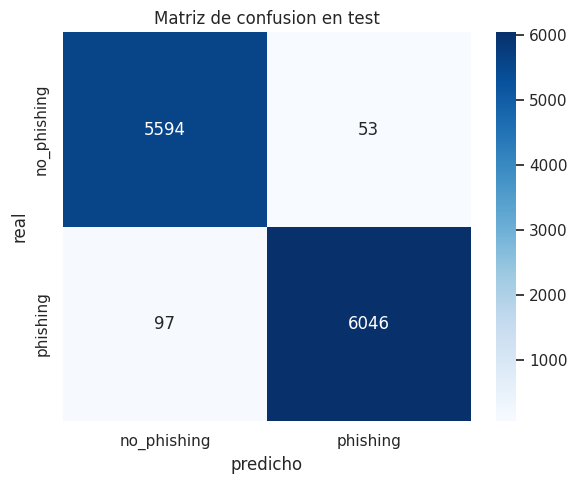

saved metrics -> artifacts_structured/test_metrics.json


In [8]:
test_metrics, y_true, y_pred, y_prob = evaluate_model(mlp, test_loader)
display(pd.DataFrame([test_metrics]).T.rename(columns={0: 'value'}))
print(classification_report(y_true, y_pred, target_names=['no_phishing', 'phishing'], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no_phishing', 'phishing'], yticklabels=['no_phishing', 'phishing'])
plt.xlabel('predicho')
plt.ylabel('real')
plt.title('Matriz de confusion en test')
plt.tight_layout()
plt.show()

pd.Series(test_metrics).to_json(TEST_METRICS_PATH, indent=2)
print('saved metrics ->', TEST_METRICS_PATH)

## 7. Inferencia

La funcion siguiente recibe campos separados, aplica la misma limpieza y devuelve una prediccion final.

In [11]:
def build_single_feature_row(subject: str, body: str, sender: str = '', receiver: str = '', date: str = '', urls: int = 0) -> pd.DataFrame:
    row = pd.Series({
        'subject': subject,
        'body': body,
        'sender': sender,
        'receiver': receiver,
        'date': date,
        'urls': urls,
    })
    record = build_record(row)
    df = pd.DataFrame([record])
    return df


def predict_email(subject: str, body: str, sender: str = '', receiver: str = '', date: str = '', urls: int = 0) -> dict:
    sample = build_single_feature_row(subject, body, sender=sender, receiver=receiver, date=date, urls=urls)
    text = sample['embedding_text'].iloc[0]
    embed = encode_batch([text])
    num = sample.reindex(columns=feature_cols, fill_value=0).astype(np.float32)
    num_scaled = scaler.transform(num)
    final_x = torch.cat([embed, torch.tensor(num_scaled, dtype=torch.float32)], dim=1).to(DEVICE)

    mlp.eval()
    with torch.inference_mode():
        logits = mlp(final_x)
        prob = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    label = int(prob.argmax())
    return {
        'label': label,
        'is_phishing': bool(label == 1),
        'prob_no_phishing': float(prob[0]),
        'prob_phishing': float(prob[1]),
    }


predict_email(
    subject='Urgent account verification required',
    body='Click the link immediately to avoid account suspension.',
    sender='Security Team <security@example.com>',
    urls=1,
)

{'label': 1,
 'is_phishing': True,
 'prob_no_phishing': 0.0006302206311374903,
 'prob_phishing': 0.9993698000907898}

## 8. Notas finales

Si quieres reentrenar solo el clasificador, puedes reutilizar los artefactos guardados en `artifacts_structured/` sin recalcular toda la parte de limpieza.